# Hidden Acquisition Shortcuts in Brain Tumour MRI: Multi-Architecture Benchmark of a Source-Robust Training Method (v4)
**Protocol (no selection bias):**
1. **Screening:** 6 architectures (ResNet18, ResNet50, DenseNet121, EfficientNet-B0, ConvNeXt-T, RegNet-Y-800MF), baseline vs proposed method, 5 group-wise folds, 1 seed.
2. **Selection on VALIDATION folds only** (never on test predictions): score = 0.5 x validation accuracy + 0.5 x validation conflict-set accuracy of the proposed method.
3. **Full study on the selected architecture:** 5 methods x 3 seeds x 5 folds, bootstrap CIs, Wilcoxon tests, background-swap causal test, Grad-CAM.
4. **Cross-architecture table:** does the proposed method help on every architecture (not just the winner)?
5. **Ensemble:** soft-voting of the top-K architectures (chosen on validation) as an extra model.

Proposed method = background-swap + acquisition scrambling + GroupDRO (groups from discovered pseudo-sources, no metadata needed).
Runtime on a Kaggle T4 is roughly 2 to 4 h (screening 60 runs + full grid ~75 runs). Quick test: `ARCHS=resnet18,efficientnet_b0 SEEDS=0 TOPK_FULL=1 ENS_K=2`.

In [1]:
import os, glob, re, json, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from PIL import Image
from tqdm.auto import tqdm
from scipy import ndimage as ndi
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import wilcoxon
from skimage.filters import threshold_otsu, gaussian
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, f1_score, adjusted_rand_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import imagehash
warnings.filterwarnings("ignore")
E = os.environ.get
DATA_ROOT = E("DATA_ROOT", "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
EXT_ROOT  = E("EXT_ROOT", "")        # optional external dataset: one folder per class (add it as a Kaggle input)
IMG, EPOCHS, BATCH, LR, DRO_ETA = 128, int(E("EPOCHS", 6)), 64, 3e-4, 0.05
ARCHS = E("ARCHS", "resnet18,resnet50,densenet121,efficientnet_b0,convnext_tiny,regnet_y_800mf").split(",")
BACKBONES = ARCHS
TOPK_FULL, ENS_K = int(E("TOPK_FULL", 1)), int(E("ENS_K", 3))
SEEDS = [int(s) for s in E("SEEDS", "0,1,2").split(",")]
NFOLD, MIN_CELL = 5, int(E("MIN_CELL", 20))
SUB = int(E("SUB", 0)) or None       # per-class subsample, debug only
OUT = "outputs"; RUNS = f"{OUT}/runs"; MODELS = f"{OUT}/models"
for d in (OUT, RUNS, MODELS): os.makedirs(d, exist_ok=True)
dev = "cuda" if torch.cuda.is_available() else "cpu"
json.dump(dict(IMG=IMG, EPOCHS=EPOCHS, LR=LR, DRO_ETA=DRO_ETA, BACKBONES=BACKBONES, SEEDS=SEEDS, NFOLD=NFOLD,
               torch=torch.__version__, torchvision=torchvision.__version__), open(f"{OUT}/config.json", "w"))
def get_w(name):
    try:
        w = torchvision.models.get_model_weights(name).DEFAULT; torchvision.models.get_model(name, weights=w); return w
    except Exception as e: print("no pretrained weights for", name, "(random init):", str(e)[:60]); return None
WEIGHTS = {b: get_w(b) for b in BACKBONES}
print(dev, BACKBONES, SEEDS)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 204MB/s]  


Downloading: "https://download.pytorch.org/models/regnet_y_800mf-58fc7688.pth" to /root/.cache/torch/hub/checkpoints/regnet_y_800mf-58fc7688.pth


100%|██████████| 24.8M/24.8M [00:00<00:00, 104MB/s] 

cuda ['resnet18', 'resnet50', 'densenet121', 'efficientnet_b0', 'convnext_tiny', 'regnet_y_800mf'] [0, 1, 2]


## 1. Data, brain masks, fingerprints, duplicate groups

In [2]:
rows = [(f, sp, c) for sp in ["Training","Testing"] for c in sorted(os.listdir(f"{DATA_ROOT}/{sp}"))
        for f in glob.glob(f"{DATA_ROOT}/{sp}/{c}/*")]
df = pd.DataFrame(rows, columns=["path","orig_split","label"])
if SUB: df = df.groupby("label").sample(SUB, random_state=0).reset_index(drop=True)
N = len(df); classes = sorted(df.label.unique()); K = len(classes)
y = df.label.map({c:i for i,c in enumerate(classes)}).values.astype(np.int64)
print(N, classes, df.label.value_counts().to_dict())

S = 256
def brain_mask(a):
    b = gaussian(a, 1.5); m = b > threshold_otsu(b)*0.5
    m = ndi.binary_fill_holes(ndi.binary_opening(m, iterations=2))
    lab, n = ndi.label(m)
    if n == 0: return np.ones_like(m)
    return lab == (np.argmax(ndi.sum(m, lab, range(1, n+1))) + 1)
rs = lambda z, mode: np.asarray(Image.fromarray(z).resize((IMG, IMG), mode))
def prep(p):
    with Image.open(p) as im: w, h = im.size; g = im.convert("L")
    g = g.resize((S,S), Image.BILINEAR); a = np.asarray(g, np.float32)/255
    m = brain_mask(a)
    if m.mean() < .05: m = np.ones_like(m)
    ys, xs = np.where(m); y0, y1, x0, x1 = ys.min(), ys.max()+1, xs.min(), xs.max()+1
    xr = rs(np.asarray(g), Image.BILINEAR); mr = rs((m*255).astype(np.uint8), Image.NEAREST) > 0
    ac = np.asarray(Image.fromarray(a[y0:y1,x0:x1]).resize((IMG,IMG), Image.BILINEAR))
    mc = rs((m[y0:y1,x0:x1]*255).astype(np.uint8), Image.NEAREST) > 0
    v = ac[mc] if mc.any() else ac.ravel()
    xc = (((ac - v.mean())/(v.std()+1e-6))*mc).astype(np.float16)
    sm = np.asarray(g.resize((32,32)), np.float32)/255
    ph = int(str(imagehash.phash(g)), 16)
    bg = a[~m] if (~m).any() else np.zeros(1)
    fp = [w, h, w/h, os.path.getsize(p)/(w*h), m.mean(), bg.mean(), bg.std(), (y1-y0)/S, (x1-x0)/S, a[m].mean(), a[m].std()]
    return xr, mr, xc, mc, sm, ph, fp

Xr = np.zeros((N,IMG,IMG), np.uint8); Xc = np.zeros((N,IMG,IMG), np.float16)
Mr = np.zeros((N,IMG,IMG), bool);     Mc = np.zeros((N,IMG,IMG), bool)
Sm = np.zeros((N,32,32), np.float32); PH = np.zeros(N, np.uint64); FP = []
for i, p in enumerate(tqdm(df.path)):
    Xr[i], Mr[i], Xc[i], Mc[i], Sm[i], PH[i], fp = prep(p); FP.append(fp)
FP = np.array(FP, np.float32); df["w"], df["h"] = FP[:,0], FP[:,1]

def pc(a): return np.unpackbits(np.ascontiguousarray(a).view(np.uint8).reshape(*a.shape,8), axis=-1).sum(-1)
cand = set()
for s in range(0, N, 64):
    ii, jj = np.where(pc(PH[s:s+64,None] ^ PH[None,:]) <= 4)
    cand |= {(a+s, b) for a, b in zip(ii, jj) if a+s < b}
Sf = Sm.reshape(N,-1); Sf = Sf - Sf.mean(1,keepdims=True); Sf /= (np.linalg.norm(Sf,axis=1,keepdims=True)+1e-8)
Ed = np.array([(a,b) for a,b in cand if Sf[a]@Sf[b] >= 0.98]).reshape(-1,2)
df["grp"] = connected_components(coo_matrix((np.ones(len(Ed)), (Ed[:,0], Ed[:,1])), shape=(N,N)), directed=False)[1] if len(Ed) else np.arange(N)
print("near-duplicate pairs:", len(Ed), "| images in multi-image groups:", int((df.groupby("grp").grp.transform("size")>1).sum()))

7200 ['glioma', 'meningioma', 'notumor', 'pituitary'] {'glioma': 1800, 'meningioma': 1800, 'notumor': 1800, 'pituitary': 1800}


  0%|          | 0/7200 [00:00<?, ?it/s]

near-duplicate pairs: 4410 | images in multi-image groups: 2008


## 2. Hidden-source discovery and validation (no metadata used)

silhouette: {2: 0.56, 3: 0.558, 4: 0.374, 5: 0.394, 6: 0.389} -> k = 2
label  glioma  meningioma  notumor  pituitary
src                                          
0        1756        1619      516       1743
1          44         181     1284         57
                       check  ARI vs main clustering
0              kmeans seed 1                   0.998
1              kmeans seed 2                   1.000
2              kmeans seed 3                   0.998
3              kmeans seed 4                   1.000
4              kmeans seed 5                   0.998
5  size/format features only                   0.958
6    intensity features only                   0.237
orig_split  Testing  Training
src                          
0              1176      4458
1               424      1142
src         0  1
size            
512x512  5014  0
630x630    90  0
442x442    45  3
428x417    41  1
468x444    24  0
504x540    23  0
300x168    21  0
359x449    16  7
src              0    1
path   

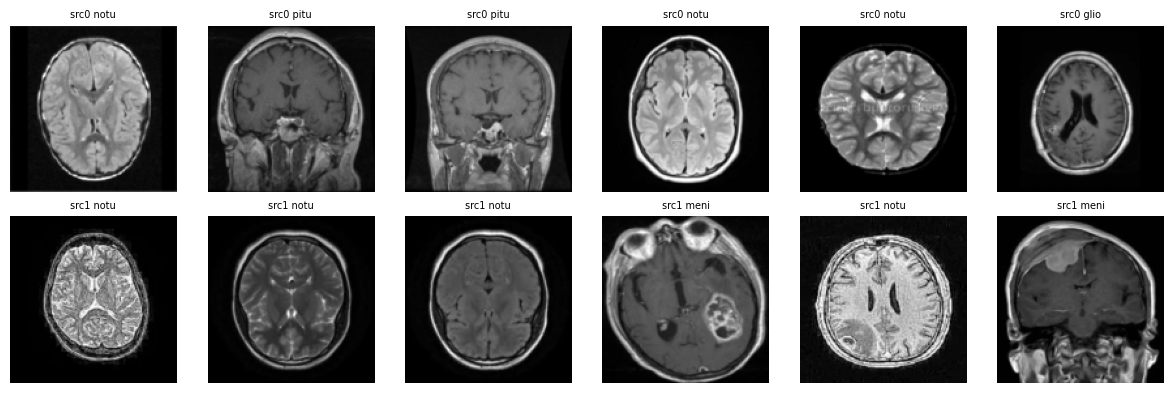

In [3]:
Z = StandardScaler().fit_transform(np.c_[np.log(FP[:,0]), np.log(FP[:,1]), FP[:,2], FP[:,3], FP[:,4], FP[:,5], FP[:,6]])
rng = np.random.RandomState(0); sub = rng.choice(N, min(N,3000), replace=False)
sc = {k: silhouette_score(Z[sub], KMeans(k, n_init=5, random_state=0).fit_predict(Z[sub])) for k in range(2,7)}
kbest = max(sc, key=sc.get)
src = KMeans(kbest, n_init=10, random_state=0).fit_predict(Z).astype(np.int64); df["src"] = src
print("silhouette:", {k: round(float(v),3) for k,v in sc.items()}, "-> k =", kbest)
ct = pd.crosstab(df.src, df.label); print(ct); ct.to_csv(f"{OUT}/source_by_class.csv")

# stability: same partition from other seeds and from independent feature subsets?
base = src; rows_ = []
for sd in range(1,6): rows_.append(("kmeans seed %d"%sd, adjusted_rand_score(base, KMeans(kbest, n_init=10, random_state=sd).fit_predict(Z))))
for nm, cols in {"size/format features only":[0,1,2,3], "intensity features only":[4,5,6]}.items():
    rows_.append((nm, adjusted_rand_score(base, KMeans(kbest, n_init=10, random_state=0).fit_predict(Z[:,cols]))))
stab = pd.DataFrame(rows_, columns=["check","ARI vs main clustering"]).round(3); print(stab); stab.to_csv(f"{OUT}/source_stability.csv", index=False)

# provenance clues: image sizes, original folder, file-name pattern
print(pd.crosstab(df.src, df.orig_split))
sz = df.assign(size=df.w.astype(int).astype(str)+"x"+df.h.astype(int).astype(str)); print(pd.crosstab(sz["size"], sz.src).sort_values(0, ascending=False).head(8))
print(pd.crosstab(df.path.map(lambda p: re.sub(r"[0-9]+", "#", os.path.basename(p))[:12]), df.src).head(8))
fig, ax = plt.subplots(kbest, 6, figsize=(12, 2*kbest), squeeze=False)
for s in range(kbest):
    ix = rng.choice(df.index[df.src==s], min(6,(df.src==s).sum()), replace=False)
    for c in range(6):
        ax[s,c].axis("off")
        if c < len(ix): ax[s,c].imshow(Xr[ix[c]], cmap="gray"); ax[s,c].set_title(f"src{s} {df.label[ix[c]][:4]}", fontsize=7)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_sources.png", dpi=130); plt.show()

In [4]:
# groups = class x source ; conflict set = images that go against the dominant source-class link
D = kbest; G = K*D; gid = (y*D + src).astype(np.int64)
cell_names = [f"{classes[g//D][:4]}|s{g%D}" for g in range(G)]
cell_n = np.bincount(gid, minlength=G); print(dict(zip(cell_names, cell_n)))
NOTU = classes.index("notumor") if "notumor" in classes else 0
ndom = int(np.argmax([(y[src==s]==NOTU).mean() for s in range(D)]))      # source richest in no-tumour images
conflict = ((y==NOTU)&(src!=ndom)) | ((y!=NOTU)&(src==ndom))
cmask = np.array([((g//D==NOTU)&(g%D!=ndom)) or ((g//D!=NOTU)&(g%D==ndom)) for g in range(G)])
okcell = cell_n >= MIN_CELL
print("conflict set size:", int(conflict.sum()), "| cells used for worst-group:", [cell_names[g] for g in range(G) if okcell[g]])
def folds_for(seed):   # group-wise (duplicate-safe) folds, stratified by class x source cell
    return [f[1] for f in StratifiedGroupKFold(NFOLD, shuffle=True, random_state=seed).split(np.zeros(N), gid, df.grp.values)]

{'glio|s0': np.int64(1756), 'glio|s1': np.int64(44), 'meni|s0': np.int64(1619), 'meni|s1': np.int64(181), 'notu|s0': np.int64(516), 'notu|s1': np.int64(1284), 'pitu|s0': np.int64(1743), 'pitu|s1': np.int64(57)}
conflict set size: 798 | cells used for worst-group: ['glio|s0', 'glio|s1', 'meni|s0', 'meni|s1', 'notu|s0', 'notu|s1', 'pitu|s0', 'pitu|s1']


## 3. Shortcut audit (class predicted without tumour information)

In [5]:
f0 = folds_for(0); te0, va0 = f0[0], f0[1]; tr0 = np.setdiff1d(np.arange(N), np.r_[te0, va0])
chance = lambda a: (a - 1/K)/(1 - 1/K)
clf = HistGradientBoostingClassifier(max_iter=200, random_state=0).fit(FP[tr0], y[tr0])
acc_fp = float((clf.predict(FP[te0]) == y[te0]).mean())
print(f"Fingerprint-only probe: acc={acc_fp:.3f}  SRI={chance(acc_fp):.3f}   (SRI 0 = no shortcut, 1 = complete shortcut)")

Fingerprint-only probe: acc=0.860  SRI=0.814   (SRI 0 = no shortcut, 1 = complete shortcut)


## 4. Models, augmentations (background swap + acquisition scrambling), GroupDRO

In [6]:
nrm = lambda a: torch.as_tensor((a/255 - .45)/.225, dtype=torch.float16).to(dev)
T  = dict(raw=nrm(Xr.astype(np.float32)), crop=torch.as_tensor(Xc).to(dev), bg=nrm((Xr*(~Mr)).astype(np.float32)))
MK = dict(raw=torch.as_tensor(Mr).to(dev), crop=torch.as_tensor(Mc).to(dev)); MK["bg"] = MK["raw"]
yt_all = torch.as_tensor(y).to(dev); gt_all = torch.as_tensor(gid).to(dev)

def make_backbone(name):
    m = torchvision.models.get_model(name, weights=WEIGHTS[name])
    if name.startswith("resnet"): return nn.Sequential(*list(m.children())[:-2]), m.fc.in_features
    if name.startswith("densenet"): return nn.Sequential(m.features, nn.ReLU()), m.classifier.in_features
    if name.startswith(("efficientnet", "convnext")): return m.features, m.classifier[-1].in_features
    if name.startswith("regnet"): return nn.Sequential(m.stem, m.trunk_output), m.fc.in_features
    raise ValueError(name)
class Net(nn.Module):
    def __init__(s, bb):
        super().__init__(); s.f, d = make_backbone(bb); s.c = nn.Linear(d, K)
    def fmap(s, x): return s.f(x.float().unsqueeze(1).expand(-1,3,-1,-1))
    def forward(s, x): return s.c(s.fmap(x).mean((2,3)))

def aug(x, mk, swap, strong):
    if np.random.rand() < .5: x = x.flip(-1); mk = mk.flip(-1)
    B = len(x)
    if swap:     # replace the background of some images by the background of another image in the batch
        j = torch.randperm(B, device=x.device); use = (torch.rand(B, device=x.device) < .5).view(-1,1,1)
        x = torch.where(use & ~mk, x[j], x)
    if strong:   # scramble acquisition cues: contrast, small affine, blur, noise
        x = x*(1 + .4*(torch.rand(B,1,1, device=x.device) - .5))
        ang = (torch.rand(B, device=x.device) - .5)*.35; s_ = 1 + (torch.rand(B, device=x.device) - .5)*.3
        th = torch.zeros(B,2,3, device=x.device)
        th[:,0,0] = s_*torch.cos(ang); th[:,0,1] = -s_*torch.sin(ang); th[:,1,0] = s_*torch.sin(ang); th[:,1,1] = s_*torch.cos(ang)
        th[:,:,2] = (torch.rand(B,2, device=x.device) - .5)*.16
        g = F.affine_grid(th, (B,1,IMG,IMG), align_corners=False)
        x = F.grid_sample(x.float().unsqueeze(1), g, padding_mode="border", align_corners=False).squeeze(1)
        if np.random.rand() < .5: x = F.avg_pool2d(x.unsqueeze(1), 3, 1, 1).squeeze(1)
        x = x + .05*torch.randn_like(x)*torch.rand(B,1,1, device=x.device)
    else: x = x*(1 + .3*(torch.rand(B,1,1, device=x.device) - .5))
    return x

@torch.no_grad()
def predx(m, x):
    m.eval(); return torch.cat([F.softmax(m(x[i:i+256]),1).cpu() for i in range(0, len(x), 256)]).numpy()
def probs(m, X, idx): return predx(m, X[torch.as_tensor(idx).to(dev)])
def gscore(pred, idx):
    c = pred == y[idx]; a = np.bincount(gid[idx], weights=c, minlength=G); n = np.bincount(gid[idx], minlength=G); ok = n >= 3
    return (a[ok]/n[ok]).mean()

def fit(bb, inp, mode, acq, tr, va, seed):      # mode: erm | dro ; acq: background swap + acquisition scrambling
    torch.manual_seed(seed); np.random.seed(seed)
    X, M = T[inp], MK[inp]; m = Net(bb).to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=EPOCHS*int(np.ceil(len(tr)/BATCH)))
    q = torch.ones(G, device=dev)/G; best = -1; scaler = torch.cuda.amp.GradScaler(enabled=(dev == "cuda"))
    for ep in range(EPOCHS):
        m.train(); perm = np.random.permutation(tr)
        for b in range(0, len(perm), BATCH):
            ix = torch.as_tensor(perm[b:b+BATCH]).to(dev)
            if len(ix) < 4: sched.step(); continue
            x = aug(X[ix], M[ix], swap=(acq and inp == "raw"), strong=acq)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")):
                lo_ = m(x)
            l = F.cross_entropy(lo_.float(), yt_all[ix], reduction="none")
            if mode == "dro":
                g = gt_all[ix]; gc = torch.bincount(g, minlength=G).float()
                gl = torch.zeros(G, device=dev).scatter_add(0, g, l)/gc.clamp(min=1)
                q = q*torch.exp(DRO_ETA*gl.detach()*(gc > 0)); q = q/q.sum(); loss = (q*gl).sum()
            else: loss = l.mean()
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        a = gscore(probs(m, X, va).argmax(1), va)
        if a >= best: best, st = a, {k:v.clone() for k,v in m.state_dict().items()}
    m.load_state_dict(st); return m

@torch.no_grad()
def swap_test(m, te):       # CAUSAL TEST: keep the brain, replace ONLY the background by one from the other source
    s = src[te]; r = np.random.RandomState(0); j = np.array([r.choice(te[s != si]) if (s != si).any() else te[i] for i, si in enumerate(s)])
    ti, tj = torch.as_tensor(te).to(dev), torch.as_tensor(j).to(dev)
    return predx(m, T["raw"][ti]).argmax(1), predx(m, torch.where(MK["raw"][ti], T["raw"][ti], T["raw"][tj])).argmax(1)
@torch.no_grad()
def feats(m, X, idx):
    m.eval(); ix = torch.as_tensor(idx).to(dev)
    return torch.cat([m.fmap(X[ix[i:i+256]]).mean((2,3)).float().cpu() for i in range(0, len(ix), 256)]).numpy()

## 5. Experiments (resumable): A) screen 6 architectures, B) select on validation, C) full study on the winner
Methods: `erm_raw` (baseline), `erm_crop`, `dro_crop`, `bgswap_raw`, `bgswap_dro_raw` (**proposed**).

In [7]:
METHODS = [("erm_raw","raw","erm",False), ("erm_crop","crop","erm",False), ("dro_crop","crop","dro",False),
           ("bgswap_raw","raw","erm",True), ("bgswap_dro_raw","raw","dro",True)]
BASE, PROP = "erm_raw", "bgswap_dro_raw"
mb = fit(ARCHS[0], "bg", "erm", False, tr0, va0, 0); acc_bg = float((probs(mb, T["bg"], te0).argmax(1) == y[te0]).mean())
print(f"Background-only CNN probe: acc={acc_bg:.3f}  SRI={chance(acc_bg):.3f}"); del mb

def run_grid(bbs, methods, seeds):
    pbar = tqdm(total=len(bbs)*len(seeds)*NFOLD*len(methods))
    for bb in bbs:
        for seed in seeds:
            folds = folds_for(seed)
            for k in range(NFOLD):
                te = folds[k]; va = folds[(k+1) % NFOLD]; tr = np.setdiff1d(np.arange(N), np.r_[te, va])
                for name, inp, mode, acq in methods:
                    f = f"{RUNS}/{bb}__{name}__s{seed}__f{k}.npz"
                    if os.path.exists(f): pbar.update(1); continue
                    m = fit(bb, inp, mode, acq, tr, va, seed); p = probs(m, T[inp], te); pv = probs(m, T[inp], va).argmax(1)
                    cv = conflict[va]; v_acc = float((pv == y[va]).mean()); v_conf = float((pv == y[va])[cv].mean()) if cv.any() else v_acc
                    sw0, sw1 = swap_test(m, te) if inp == "raw" else (-np.ones(len(te), int), -np.ones(len(te), int))
                    probe = np.nan
                    if k == 0 and seed == SEEDS[0]:
                        sub = np.random.RandomState(0).choice(tr, min(2500, len(tr)), replace=False)
                        lr = LogisticRegression(max_iter=300, class_weight="balanced").fit(feats(m, T[inp], sub), src[sub])
                        probe = balanced_accuracy_score(src[te], lr.predict(feats(m, T[inp], te)))
                        torch.save(m.state_dict(), f"{MODELS}/{bb}__{name}.pt")
                    np.savez(f, te=te, pred=p.argmax(1), conf=p.max(1), prob=p.astype(np.float16), sw0=sw0, sw1=sw1, probe=probe,
                             v_acc=v_acc, v_conf=v_conf, v_gs=gscore(pv, va))
                    del m; torch.cuda.empty_cache() if dev == "cuda" else None; pbar.update(1)
# A) screening: all architectures, baseline vs proposed, first seed only
run_grid(ARCHS, [mm for mm in METHODS if mm[0] in (BASE, PROP)], [SEEDS[0]])

Background-only CNN probe: acc=0.902  SRI=0.869


  0%|          | 0/60 [00:00<?, ?it/s]

In [8]:
# B) selection using VALIDATION folds only (no test leakage)
sel = []
for f in glob.glob(f"{RUNS}/*.npz"):
    bb, nm, s_, k_ = os.path.basename(f)[:-4].split("__")
    if int(s_[1:]) == SEEDS[0] and nm in (BASE, PROP):
        z = np.load(f); sel.append(dict(arch=bb, method=nm, k=int(k_[1:]), v_acc=float(z["v_acc"]), v_conf=float(z["v_conf"]), v_gs=float(z["v_gs"])))
sel = pd.DataFrame(sel); sel = sel.groupby(["arch","method"]).agg(folds=("k","count"), v_acc=("v_acc","mean"), v_conf=("v_conf","mean"), v_gs=("v_gs","mean"))
sel = sel[sel.folds == NFOLD].copy(); sel["val_score"] = 0.5*sel.v_acc + 0.5*sel.v_conf
print(sel.round(4).to_string()); sel.to_csv(f"{OUT}/table_selection_validation.csv")
prop_rank = sel.xs(PROP, level="method").sort_values("val_score", ascending=False)
FINAL_BB = list(prop_rank.index[:TOPK_FULL]); ENS_BB = list(prop_rank.index[:ENS_K]); ANALYSIS_BB = FINAL_BB
print("\nSelected architecture(s) for the full study:", FINAL_BB, "| ensemble members:", ENS_BB)

                                folds   v_acc  v_conf    v_gs  val_score
arch            method                                                  
convnext_tiny   bgswap_dro_raw      5  0.9675  0.9329  0.9171     0.9502
                erm_raw             5  0.9756  0.9310  0.9130     0.9533
densenet121     bgswap_dro_raw      5  0.9434  0.9206  0.8947     0.9320
                erm_raw             5  0.9639  0.9271  0.8990     0.9455
efficientnet_b0 bgswap_dro_raw      5  0.9286  0.8997  0.8572     0.9142
                erm_raw             5  0.9695  0.9130  0.8797     0.9412
regnet_y_800mf  bgswap_dro_raw      5  0.9167  0.8907  0.8478     0.9037
                erm_raw             5  0.9634  0.8989  0.8741     0.9311
resnet18        bgswap_dro_raw      5  0.9079  0.8863  0.8457     0.8971
                erm_raw             5  0.9595  0.9092  0.8828     0.9343
resnet50        bgswap_dro_raw      5  0.9369  0.9056  0.8688     0.9213
                erm_raw             5  0.9727  0.93

In [9]:
# C) full study on the selected architecture(s): all methods, all seeds
run_grid(FINAL_BB, METHODS, SEEDS)

  0%|          | 0/75 [00:00<?, ?it/s]

## 6. Results: overall vs conflict-set vs worst-group, with calibration

In [10]:
def load_runs():
    R = {}
    for f in sorted(glob.glob(f"{RUNS}/*.npz")):
        bb, name, s, k = os.path.basename(f)[:-4].split("__"); z = np.load(f)
        R.setdefault((bb, name, int(s[1:])), []).append(dict(k=int(k[1:]), **{a: z[a] for a in z.files}))
    out = {}
    for key, runs in R.items():
        if len(runs) < NFOLD: continue
        d = dict(runs=sorted(runs, key=lambda r: r["k"]))
        for a in ("pred","conf","sw0","sw1"):
            v = np.zeros(N, np.float32 if a == "conf" else np.int64)
            for r in d["runs"]: v[r["te"]] = r[a]
            d[a] = v
        d["prob"] = np.zeros((N, K), np.float32)
        for r in d["runs"]: d["prob"][r["te"]] = r["prob"]
        out[key] = d
    return out
R = load_runs(); print(len(R), "complete (backbone, method, seed) combinations")
def ece(conf, cor, nb=15):
    e = 0; bins = np.linspace(0, 1, nb+1)
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = (conf > lo) & (conf <= hi); e += s.mean()*abs(cor[s].mean() - conf[s].mean()) if s.any() else 0
    return e
def metrics_all(pred, conf):
    cor = pred == y; a = np.bincount(gid, weights=cor, minlength=G)/np.maximum(cell_n, 1)
    return dict(acc=cor.mean(), macro_f1=f1_score(y, pred, average="macro"), conflict_acc=cor[conflict].mean(),
                avg_group=a[okcell].mean(), worst_group=a[okcell].min(), ece=ece(conf, cor))
rows = [dict(backbone=bb, method=nm, seed=s, **metrics_all(d["pred"], d["conf"])) for (bb, nm, s), d in R.items()]
per_seed = pd.DataFrame(rows); per_seed.to_csv(f"{OUT}/per_seed_metrics.csv", index=False)
order = [m[0] for m in METHODS]
g = per_seed.groupby(["backbone","method"])
mean_, std_ = g.mean(numeric_only=True).drop(columns="seed"), g.std(numeric_only=True).drop(columns="seed")
tab = (mean_.round(4).astype(str) + " +/- " + std_.fillna(0).round(4).astype(str)).reindex(
    pd.MultiIndex.from_product([ANALYSIS_BB, order], names=["backbone","method"])).dropna(how="all")
print(tab.to_string()); tab.to_csv(f"{OUT}/table_main.csv"); mean_.to_csv(f"{OUT}/table_main_mean.csv")

25 complete (backbone, method, seed) combinations
                                            acc           macro_f1       conflict_acc          avg_group        worst_group                ece
backbone      method                                                                                                                          
convnext_tiny erm_raw         0.9736 +/- 0.0017  0.9736 +/- 0.0017  0.9344 +/- 0.0052  0.9148 +/- 0.0151   0.5985 +/- 0.086  0.0154 +/- 0.0032
              erm_crop        0.9723 +/- 0.0012  0.9723 +/- 0.0012  0.9319 +/- 0.0051  0.9022 +/- 0.0064  0.4924 +/- 0.0347  0.0161 +/- 0.0011
              dro_crop        0.9681 +/- 0.0022  0.9682 +/- 0.0022  0.9336 +/- 0.0066  0.9034 +/- 0.0081  0.6061 +/- 0.0572   0.013 +/- 0.0026
              bgswap_raw      0.9714 +/- 0.0033  0.9714 +/- 0.0033   0.939 +/- 0.0051  0.9103 +/- 0.0097   0.553 +/- 0.0473  0.0125 +/- 0.0014
              bgswap_dro_raw  0.9618 +/- 0.0024  0.9618 +/- 0.0025  0.9319 +/- 0.0122  0.906

## 7. Statistics: duplicate-aware bootstrap CIs, paired differences, Wilcoxon tests

        backbone          method  conflict_CI     worst_CI              d_conflict                 d_worst  P_better  wilcoxon_p
0  convnext_tiny         erm_raw  0.914-0.952  0.475-0.730                     NaN                     NaN       NaN         NaN
1  convnext_tiny        erm_crop  0.912-0.950  0.350-0.642  -0.002 [-0.011,+0.007]  -0.106 [-0.174,-0.039]     0.316      0.6378
2  convnext_tiny        dro_crop  0.912-0.952  0.458-0.745  -0.001 [-0.015,+0.013]  +0.009 [-0.093,+0.113]     0.467      0.8261
3  convnext_tiny      bgswap_raw  0.919-0.958  0.413-0.696  +0.005 [-0.006,+0.015]  -0.044 [-0.146,+0.073]     0.824      0.3627
4  convnext_tiny  bgswap_dro_raw  0.911-0.951  0.462-0.726  -0.002 [-0.015,+0.010]  -0.005 [-0.119,+0.106]     0.382      0.9750
         convnext_tiny|erm_raw  convnext_tiny|erm_crop  convnext_tiny|dro_crop  convnext_tiny|bgswap_raw  convnext_tiny|bgswap_dro_raw     n
glio|s0                  0.981                   0.982                   0.973       

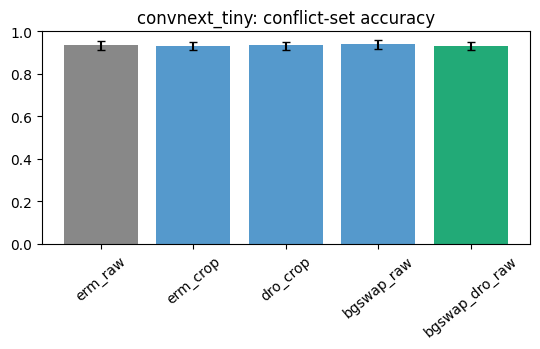

In [11]:
ug, gi = np.unique(df.grp.values, return_inverse=True); NG = len(ug)
num_mat = lambda cb: (lambda M: (np.add.at(M, (gi, gid), cb), M)[1])(np.zeros((NG, G)))
den = np.zeros((NG, G)); np.add.at(den, (gi, gid), 1.0)
B = 1000; IX = np.random.RandomState(0).randint(0, NG, (B, NG))
def boot(cb):      # resamples duplicate-groups (not images) so near-duplicates cannot shrink the intervals
    num = num_mat(cb); conf_, worst_ = [], []
    for ix in IX:
        n_, d_ = num[ix].sum(0), den[ix].sum(0); cell = n_/np.maximum(d_, 1)
        conf_.append(n_[cmask].sum()/d_[cmask].sum()); worst_.append(cell[okcell & (d_ > 0)].min())
    return np.array(conf_), np.array(worst_)
stats_rows = []; bootres = {}
for bb in ANALYSIS_BB:
    for nm in order:
        ss = [s for s in SEEDS if (bb, nm, s) in R]
        if not ss: continue
        cb = np.mean([(R[(bb, nm, s)]["pred"] == y) for s in ss], 0); bootres[(bb, nm)] = boot(cb)
    for nm in order:
        if (bb, nm) not in bootres: continue
        c, w = bootres[(bb, nm)]; r = dict(backbone=bb, method=nm,
            conflict_CI=f"{np.percentile(c,2.5):.3f}-{np.percentile(c,97.5):.3f}", worst_CI=f"{np.percentile(w,2.5):.3f}-{np.percentile(w,97.5):.3f}")
        if nm != BASE and (bb, BASE) in bootres:
            dc = c - bootres[(bb, BASE)][0]; dw = w - bootres[(bb, BASE)][1]
            r.update(d_conflict=f"{dc.mean():+.3f} [{np.percentile(dc,2.5):+.3f},{np.percentile(dc,97.5):+.3f}]",
                     d_worst=f"{dw.mean():+.3f} [{np.percentile(dw,2.5):+.3f},{np.percentile(dw,97.5):+.3f}]", P_better=round(float((dc > 0).mean()), 3))
            pa, pb = [], []     # paired per (seed, fold) conflict-set accuracy
            for s in SEEDS:
                if (bb, nm, s) in R and (bb, BASE, s) in R:
                    for ra, rb in zip(R[(bb, nm, s)]["runs"], R[(bb, BASE, s)]["runs"]):
                        cm = conflict[ra["te"]]
                        if cm.any(): pa.append((ra["pred"] == y[ra["te"]])[cm].mean()); pb.append((rb["pred"] == y[rb["te"]])[cm].mean())
            try: r["wilcoxon_p"] = round(float(wilcoxon(np.array(pa) - np.array(pb)).pvalue), 4)
            except Exception: r["wilcoxon_p"] = np.nan
        stats_rows.append(r)
stats_df = pd.DataFrame(stats_rows); print(stats_df.to_string()); stats_df.to_csv(f"{OUT}/table_stats.csv", index=False)

cellacc = {}
for (bb, nm), _ in bootres.items():
    ss = [s for s in SEEDS if (bb, nm, s) in R]; cellacc[f"{bb}|{nm}"] = np.mean([np.bincount(gid, weights=(R[(bb, nm, s)]["pred"] == y), minlength=G)/np.maximum(cell_n, 1) for s in ss], 0)
cells_df = pd.DataFrame(cellacc, index=cell_names).round(3); cells_df["n"] = cell_n; print(cells_df.to_string()); cells_df.to_csv(f"{OUT}/table_cells.csv")
fig, axs = plt.subplots(1, len(ANALYSIS_BB), figsize=(5.5*len(ANALYSIS_BB), 3.6), squeeze=False)
for a, bb in zip(axs[0], ANALYSIS_BB):
    ms = [m for m in order if (bb, m) in bootres]; mu = [bootres[(bb, m)][0].mean() for m in ms]
    lo = [mu[i] - np.percentile(bootres[(bb, m)][0], 2.5) for i, m in enumerate(ms)]; hi = [np.percentile(bootres[(bb, m)][0], 97.5) - mu[i] for i, m in enumerate(ms)]
    a.bar(ms, mu, yerr=[lo, hi], capsize=3, color=["#888" if m == BASE else "#2a7" if "bgswap_dro" in m else "#59c" for m in ms]); a.set_title(f"{bb}: conflict-set accuracy"); a.set_ylim(0, 1); a.tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_conflict_acc.png", dpi=150); plt.show()

## 7b. Cross-architecture check: does the proposed method help on EVERY architecture? (seed 0, validation-free test of generality)

In [12]:
rows = []
for bb in ARCHS:
    if (bb, BASE, SEEDS[0]) not in R or (bb, PROP, SEEDS[0]) not in R: continue
    A, P = R[(bb, BASE, SEEDS[0])], R[(bb, PROP, SEEDS[0])]
    bA, bP = boot((A["pred"] == y).astype(float)), boot((P["pred"] == y).astype(float)); dc, dw = bP[0] - bA[0], bP[1] - bA[1]
    mA, mP = metrics_all(A["pred"], A["conf"]), metrics_all(P["pred"], P["conf"])
    rows.append(dict(arch=bb, val_score=sel.loc[(bb, PROP), "val_score"] if (bb, PROP) in sel.index else np.nan,
        base_acc=mA["acc"], prop_acc=mP["acc"], base_conflict=mA["conflict_acc"], prop_conflict=mP["conflict_acc"],
        d_conflict=f"{dc.mean():+.3f} [{np.percentile(dc,2.5):+.3f},{np.percentile(dc,97.5):+.3f}]", base_worst=mA["worst_group"], prop_worst=mP["worst_group"],
        d_worst=f"{dw.mean():+.3f} [{np.percentile(dw,2.5):+.3f},{np.percentile(dw,97.5):+.3f}]", P_better=round(float((dc > 0).mean()), 3), base_ece=mA["ece"], prop_ece=mP["ece"]))
cross = pd.DataFrame(rows).round(4); print(cross.to_string()); cross.to_csv(f"{OUT}/table_cross_architecture.csv", index=False)
print("Architectures where proposed > baseline on conflict acc:", int((cross.prop_conflict > cross.base_conflict).sum()), "of", len(cross))

              arch  val_score  base_acc  prop_acc  base_conflict  prop_conflict              d_conflict  base_worst  prop_worst                 d_worst  P_better  base_ece  prop_ece
0         resnet18     0.8971    0.9582    0.9043         0.8935         0.8546  -0.039 [-0.072,-0.008]      0.3636      0.3636  -0.004 [-0.158,+0.160]     0.009    0.0138    0.0343
1         resnet50     0.9213    0.9692    0.9351         0.9073         0.9060  -0.001 [-0.026,+0.026]      0.4773      0.4773  -0.001 [-0.125,+0.130]     0.413    0.0132    0.0154
2      densenet121     0.9320    0.9657    0.9401         0.9185         0.9010  -0.017 [-0.042,+0.007]      0.2727      0.4091  +0.133 [-0.025,+0.286]     0.065    0.0070    0.0076
3  efficientnet_b0     0.9142    0.9658    0.9278         0.9048         0.8960  -0.009 [-0.038,+0.017]      0.4545      0.3636  -0.091 [-0.256,+0.074]     0.260    0.0095    0.0100
4    convnext_tiny     0.9502    0.9726    0.9628         0.9386         0.9185  -0.020 [-

## 7c. Ensemble of the top architectures (members chosen on validation)

In [13]:
rows = []
for nm in (BASE, PROP):
    use = [b for b in ENS_BB if (b, nm, SEEDS[0]) in R]
    if len(use) < 2: continue
    P = np.mean([R[(b, nm, SEEDS[0])]["prob"] for b in use], 0); pred = P.argmax(1); conf = P.max(1)
    c, w = boot((pred == y).astype(float)); r = metrics_all(pred, conf)
    r.update(model=f"{nm} ensemble", members="+".join(use), conflict_CI=f"{np.percentile(c,2.5):.3f}-{np.percentile(c,97.5):.3f}", worst_CI=f"{np.percentile(w,2.5):.3f}-{np.percentile(w,97.5):.3f}"); rows.append(r)
for nm in (BASE, PROP):
    b = ENS_BB[0]
    if (b, nm, SEEDS[0]) in R:
        c, w = boot((R[(b, nm, SEEDS[0])]["pred"] == y).astype(float)); r = metrics_all(R[(b, nm, SEEDS[0])]["pred"], R[(b, nm, SEEDS[0])]["conf"])
        r.update(model=f"{nm} single ({b})", members=b, conflict_CI=f"{np.percentile(c,2.5):.3f}-{np.percentile(c,97.5):.3f}", worst_CI=f"{np.percentile(w,2.5):.3f}-{np.percentile(w,97.5):.3f}"); rows.append(r)
ens_df = pd.DataFrame(rows).set_index("model").round(4); print(ens_df.to_string()); ens_df.to_csv(f"{OUT}/table_ensemble.csv")

                                          acc  macro_f1  conflict_acc  avg_group  worst_group     ece                             members  conflict_CI     worst_CI
model                                                                                                                                                              
erm_raw ensemble                       0.9782    0.9782        0.9386     0.9137       0.5227  0.0091  convnext_tiny+densenet121+resnet50  0.917-0.957  0.379-0.690
bgswap_dro_raw ensemble                0.9644    0.9644        0.9298     0.9006       0.5455  0.0239  convnext_tiny+densenet121+resnet50  0.905-0.951  0.378-0.700
erm_raw single (convnext_tiny)         0.9726    0.9727        0.9386     0.9222       0.6364  0.0189                       convnext_tiny  0.916-0.958  0.485-0.787
bgswap_dro_raw single (convnext_tiny)  0.9628    0.9628        0.9185     0.8990       0.6364  0.0121                       convnext_tiny  0.886-0.945  0.481-0.769


## 8. Mechanism: causal background-swap test and source leakage inside the embedding

In [14]:
rows = []
for (bb, nm, s), d in R.items():
    if (d["sw0"] < 0).all(): continue
    flip = d["sw0"] != d["sw1"]
    rows.append(dict(backbone=bb, method=nm, seed=s, flip_rate=flip.mean(), flip_rate_conflict=flip[conflict].mean(),
                     acc_clean=(d["sw0"] == y).mean(), acc_bgswap=(d["sw1"] == y).mean(), acc_bgswap_conflict=(d["sw1"] == y)[conflict].mean()))
swap_df = pd.DataFrame(rows).groupby(["backbone","method"]).mean(numeric_only=True).drop(columns="seed").round(4)
print("Background-swap test (lower flip_rate = less background dependence):"); print(swap_df.to_string()); swap_df.to_csv(f"{OUT}/table_bgswap.csv")
rows = [dict(backbone=bb, method=nm, source_from_embedding_bal_acc=float(np.nanmax([r["probe"] for r in d["runs"]])))
        for (bb, nm, s), d in R.items() if s == SEEDS[0]]
probe_df = pd.DataFrame(rows).set_index(["backbone","method"]).round(3); print("\nSource decodable from embedding (0.5 = hidden, 1 = fully encoded):"); print(probe_df.to_string()); probe_df.to_csv(f"{OUT}/table_probe.csv")

Background-swap test (lower flip_rate = less background dependence):
                                flip_rate  flip_rate_conflict  acc_clean  acc_bgswap  acc_bgswap_conflict
backbone        method                                                                                   
convnext_tiny   bgswap_dro_raw     0.0137              0.0167     0.9618      0.9585               0.9227
                bgswap_raw         0.0095              0.0092     0.9714      0.9690               0.9382
                erm_raw            0.0440              0.0359     0.9736      0.9404               0.9244
densenet121     bgswap_dro_raw     0.0324              0.0401     0.9401      0.9336               0.8935
                erm_raw            0.1226              0.0326     0.9657      0.8601               0.9048
efficientnet_b0 bgswap_dro_raw     0.0504              0.0401     0.9278      0.9111               0.8997
                erm_raw            0.1585              0.0464     0.9658      0.828

## 9. Explainability figure (Grad-CAM on conflict images)

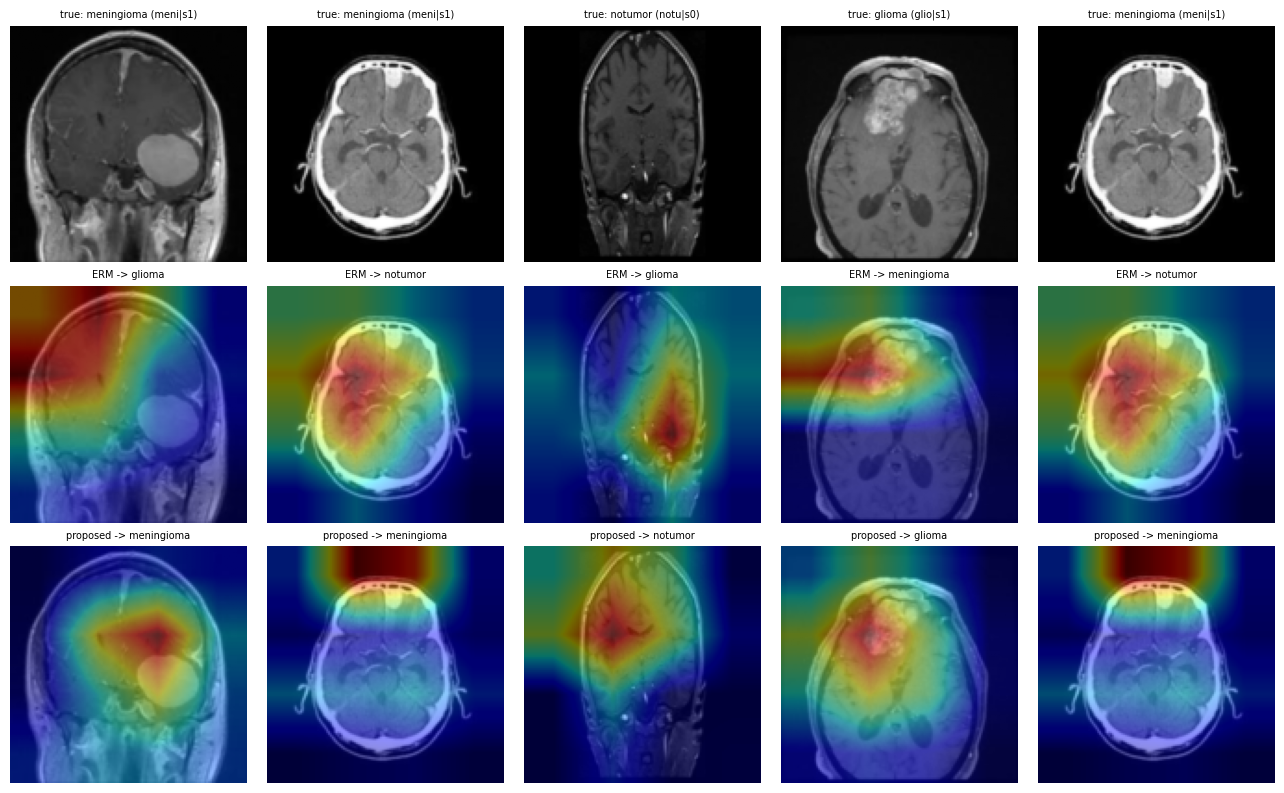

In [15]:
def gradcam(m, X, i):
    m.eval(); x = X[i:i+1]
    with torch.enable_grad():
        f = m.fmap(x); lo = m.c(f.mean((2,3))); c = int(lo.argmax(1)); gr = torch.autograd.grad(lo[0, c], f)[0]
        cam = F.relu((gr.mean((2,3), keepdim=True)*f).sum(1, keepdim=True)).detach()
    cam = F.interpolate(cam, size=(IMG,IMG), mode="bilinear")[0,0]; return (cam/(cam.max() + 1e-8)).cpu().numpy(), c
bb = FINAL_BB[0]; pa, pb_ = f"{MODELS}/{bb}__erm_raw.pt", f"{MODELS}/{bb}__bgswap_dro_raw.pt"
if os.path.exists(pa) and os.path.exists(pb_) and (bb, "erm_raw", SEEDS[0]) in R:
    ma, mb_ = Net(bb).to(dev), Net(bb).to(dev); ma.load_state_dict(torch.load(pa)); mb_.load_state_dict(torch.load(pb_))
    te = R[(bb, "erm_raw", SEEDS[0])]["runs"][0]["te"]; te = te[conflict[te]]
    pr_a = probs(ma, T["raw"], te).argmax(1); pr_b = probs(mb_, T["raw"], te).argmax(1)
    pick = te[(pr_a != y[te]) & (pr_b == y[te])][:5]; pick = pick if len(pick) else te[:5]
    fig, axs = plt.subplots(3, len(pick), figsize=(2.6*len(pick), 8), squeeze=False)
    for j, i in enumerate(pick):
        ca, pa_ = gradcam(ma, T["raw"], i); cb_, pb2 = gradcam(mb_, T["raw"], i)
        for r, (im, t) in enumerate([(None, f"true: {classes[y[i]]} ({cell_names[gid[i]]})"), (ca, f"ERM -> {classes[pa_]}"), (cb_, f"proposed -> {classes[pb2]}")]):
            axs[r,j].imshow(Xr[i], cmap="gray"); axs[r,j].axis("off"); axs[r,j].set_title(t, fontsize=7)
            if im is not None: axs[r,j].imshow(im, cmap="jet", alpha=.45)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_gradcam.png", dpi=150); plt.show()
else: print("Models for the Grad-CAM figure not found (run section 5 first).")

## 10. External validation (strongly recommended for journals)
Add a second brain-MRI dataset as a Kaggle input with **one folder per class** (names containing `glioma`, `meningioma`, `pituitary`, and `no`/`normal`/`notumor`), then set `EXT_ROOT`. Models trained on the main dataset (fold 0, first seed) are tested without any retraining.

In [16]:
if EXT_ROOT and os.path.isdir(EXT_ROOT):
    def cls_of(n):
        n = n.lower()
        for k, c in [("glioma","glioma"), ("meningioma","meningioma"), ("pituitary","pituitary")]:
            if k in n and c in classes: return classes.index(c)
        if any(t in n for t in ("notumor","no_tumor","no tumor","normal","healthy")) or n in ("no","non"): return classes.index("notumor")
        return None
    items = [(f, cls_of(os.path.basename(d))) for d in glob.glob(f"{EXT_ROOT}/**/", recursive=True) for f in glob.glob(d + "*") if f.lower().endswith((".jpg",".jpeg",".png"))]
    items = [(f, c) for f, c in items if c is not None]; print(len(items), "external images")
    EX = [prep(f) for f, _ in tqdm(items)]; ey = np.array([c for _, c in items])
    ET = dict(raw=nrm(np.stack([e[0] for e in EX]).astype(np.float32)), crop=torch.as_tensor(np.stack([e[2] for e in EX])).to(dev))
    rows = []
    for bb in BACKBONES:
        for nm, inp, mode, acq in METHODS:
            pth = f"{MODELS}/{bb}__{nm}.pt"
            if not os.path.exists(pth): continue
            m = Net(bb).to(dev); m.load_state_dict(torch.load(pth)); pr = predx(m, ET[inp]).argmax(1)
            rows.append(dict(backbone=bb, method=nm, ext_acc=(pr == ey).mean(), ext_macro_f1=f1_score(ey, pr, average="macro", labels=np.unique(ey))))
    ext_df = pd.DataFrame(rows).round(4); print(ext_df.to_string()); ext_df.to_csv(f"{OUT}/table_external.csv", index=False)
else: print("EXT_ROOT not set: skipping external validation.")

EXT_ROOT not set: skipping external validation.


## 11. Export and paper checklist

In [17]:
with open(f"{OUT}/tables.tex", "w") as fh:
    for nm_, t in [("main", mean_.round(3)), ("stats", stats_df), ("bgswap", swap_df), ("probe", probe_df)]: fh.write(f"% {nm_}\n" + t.to_latex() + "\n")
print("Saved: ", sorted(os.listdir(OUT)))
print(f"Audit numbers for the paper: fingerprint-only acc={acc_fp:.3f} (SRI {chance(acc_fp):.3f}), background-only CNN acc={acc_bg:.3f} (SRI {chance(acc_bg):.3f}); conflict set n={int(conflict.sum())}")

Saved:  ['config.json', 'fig_conflict_acc.png', 'fig_gradcam.png', 'fig_sources.png', 'models', 'per_seed_metrics.csv', 'runs', 'source_by_class.csv', 'source_stability.csv', 'table_bgswap.csv', 'table_cells.csv', 'table_cross_architecture.csv', 'table_ensemble.csv', 'table_main.csv', 'table_main_mean.csv', 'table_probe.csv', 'table_selection_validation.csv', 'table_stats.csv', 'tables.tex']
Audit numbers for the paper: fingerprint-only acc=0.860 (SRI 0.814), background-only CNN acc=0.902 (SRI 0.869); conflict set n=798


**Before submission:** (1) literature search for 'shortcut learning', 'dataset bias', 'GroupDRO', 'brain tumor MRI leakage' and position your contribution against them; (2) report all negative results; (3) state pseudo-sources are proxies; (4) release code and the list of duplicate groups; (5) add a second dataset (section 10) and, if possible, radiologist review of the conflict images; (6) check the target journal's current impact factor in JCR.

In [ ]:
print("All preceding cells executed successfully!")
